<a href="https://colab.research.google.com/github/harjussingh/TIRP-Team02/blob/main/Symptom_Severness_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
import numpy as np
import pandas as pd

In [102]:
INPUT_CSV = "/content/drive/MyDrive/Dataset/Symptoms and diseases dataset.csv"
df = pd.read_csv(INPUT_CSV)

In [103]:
DISEASE_COL = 'diseases'

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

if DISEASE_COL not in df.columns:
    raise ValueError("Column 'diseases' not found")

# Clean text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

df = df.dropna()
df = df.drop_duplicates()

In [104]:
min_samples = 50
df = df[df['diseases'].map(df['diseases'].value_counts()) >= min_samples]

In [105]:
disease_counts = df['diseases'].value_counts().reset_index()
disease_counts.columns = ['disease_name', 'row_count']

In [106]:
unique_diseases = df["diseases"].unique()
print("Total unique diseases:", len(unique_diseases))
print(unique_diseases)

Total unique diseases: 413
['panic disorder' 'atrophic vaginitis' 'fracture of the hand'
 'cellulitis or abscess of mouth' 'eye alignment disorder'
 'headache after lumbar puncture' 'vaginitis' 'sick sinus syndrome'
 'tinnitus of unknown cause' 'glaucoma' 'eating disorder'
 'transient ischemic attack' 'pyelonephritis' 'chronic pain disorder'
 'problem during pregnancy' 'injury to the hand' 'choledocholithiasis'
 'cirrhosis' 'thoracic aortic aneurysm' 'diabetic retinopathy'
 'fibromyalgia' 'ischemia of the bowel' 'peritonitis' 'acute pancreatitis'
 'thrombophlebitis' 'asthma' 'restless leg syndrome' 'induced abortion'
 'teething syndrome' 'infectious gastroenteritis' 'acute sinusitis'
 'substance-related mental disorder' 'postpartum depression'
 'coronary atherosclerosis' 'spondylitis' 'uterine fibroids' 'chalazion'
 'vaginal yeast infection' 'ingrown toe nail' 'pulmonary eosinophilia'
 'corneal disorder' 'intestinal malabsorption' 'viral warts' 'stroke'
 'pilonidal cyst' 'alopecia' 'pe

## Cell 1 — The Curated Disease Dictionary
Each entry: `'disease_name_exact_as_in_csv': ats_level`

**ATS Levels:**
- `1` = Resuscitation (Immediate)
- `2` = Emergency (≤10 min)
- `3` = Urgent (≤30 min)
- `4` = Semi-Urgent (≤60 min)
- `5` = Non-Urgent (≤120 min)



In [107]:
# ══════════════════════════════════════════════════════════════════════════════
#  SELECTED DISEASE LIST — Indigenous Australian Clinical Triage System
#
#  Disease names below are EXACT matches to your disease_list.txt
#  Format: 'disease name as in csv' : ATS_level (1=most urgent, 5=least)
# ══════════════════════════════════════════════════════════════════════════════
SELECTED_DISEASES = {

    # 🔴 ATS 1 — CRITICAL
    "heart attack": 1,
    "cardiac arrest": 1,
    "stroke": 1,
    "sepsis": 1,
    "meningitis": 1,

    # 🟠 ATS 2 — EMERGENCY
    "pulmonary embolism": 2,
    "appendicitis": 2,
    "acute pancreatitis": 2,
    "ectopic pregnancy": 2,
    "gastrointestinal hemorrhage": 2,
    "acute kidney injury": 2,
    "preeclampsia": 2,
    "peritonitis": 2,
    "alcohol withdrawal": 2,

    # 🟡 ATS 3 — URGENT
    "pneumonia": 3,
    "asthma": 3,
    "chronic obstructive pulmonary disease (copd)": 3,
    "pyelonephritis": 3,
    "kidney stone": 3,
    "cholecystitis": 3,
    "angina": 3,
    "deep vein thrombosis (dvt)": 3,
    "diverticulitis": 3,
    "acute sinusitis": 3,
    "acute bronchitis": 3,
    "acute bronchiolitis": 3,
    "intestinal obstruction": 3,
    "liver disease": 3,
    "cirrhosis": 3,
    "fracture of the leg": 3,
    "fracture of the arm": 3,
    "fracture of the rib": 3,
    "concussion": 3,
    "pneumothorax": 3,
    "atrial fibrillation": 3,
    "pericarditis": 3,
    "encephalitis": 3,
    "endocarditis": 3,
    "osteomyelitis": 3,
    "septic arthritis": 3,
    "strep throat": 3,
    "hyperemesis gravidarum": 3,

    # 🔵 ATS 4 — SEMI-URGENT (COMMON GP)
    "urinary tract infection": 4,
    "otitis media": 4,
    "conjunctivitis": 4,
    "cataract": 4,
    "glaucoma": 4,
    "hypertension": 4,
    "diabetes": 4,
    "anxiety": 4,
    "depression": 4,
    "panic disorder": 4,
    "chronic back pain": 4,
    "osteoarthritis": 4,
    "rheumatoid arthritis": 4,
    "gout": 4,
    "eczema": 4,
    "contact dermatitis": 4,
    "psoriasis": 4,
    "scabies": 4,
    "impetigo": 4,
    "fungal infection of the skin": 4,
    "iron deficiency anemia": 4,
    "gastritis": 4,
    "gastroesophageal reflux disease (gerd)": 4,
    "infectious gastroenteritis": 4,
    "tonsillitis": 4,
    "cystitis": 4,
    "prostatitis": 4,
    "pelvic inflammatory disease": 4,
    "chlamydia": 4,
    "gonorrhea": 4,
    "multiple sclerosis": 4,
    "epilepsy": 4,
    "migraine": 4,
    "tension headache": 4,
    "fibromyalgia": 4,
    "hypothyroidism": 4,
    "polycystic ovarian syndrome (pcos)": 4,
    "endometriosis": 4,
    "ovarian cyst": 4,
    "smoking or tobacco addiction": 4,
    "alcohol abuse": 4,
    "drug abuse": 4,
    "attention deficit hyperactivity disorder (adhd)": 4,
    "autism": 4,
    "dementia": 4,
    "parkinson disease": 4,

    # 🟢 ATS 5 — COMMON / MILD (VERY IMPORTANT)
    "common cold": 5,
    "flu": 5,
    "viral infection": 5,
    "upper respiratory infection": 5,
    "food poisoning": 5,
    "seasonal allergies (hay fever)": 5,
    "allergy": 5,
    "hemorrhoids": 5,
    "chronic constipation": 5,
    "irritable bowel syndrome": 5,
    "dental caries": 5,
    "gum disease": 5,
    "acne": 5,
    "seborrheic dermatitis": 5,
    "insect bite": 5,
    "varicose veins": 5,
    "osteoporosis": 5,
    "macular degeneration": 5,
    "dry eye of unknown cause": 5
}

ATS_LABELS = {
    1: 'Resuscitation',
    2: 'Emergency',
    3: 'Urgent',
    4: 'Semi-Urgent',
    5: 'Non-Urgent',
}

df = df[df["diseases"].isin(SELECTED_DISEASES.keys())]

df["ats_level"] = df["diseases"].map(SELECTED_DISEASES)

df["ats_label"] = df["ats_level"].map(ATS_LABELS)

In [108]:
filtered_df = df[df[DISEASE_COL].isin(SELECTED_DISEASES.keys())].drop_duplicates()

print(filtered_df[DISEASE_COL].nunique())
print(filtered_df[DISEASE_COL].value_counts())

missing = set(SELECTED_DISEASES.keys()) - set(filtered_df[DISEASE_COL].unique())
print(f"Missing diseases: {len(missing)}")

95
diseases
cystitis                       1219
diverticulitis                 1214
gastrointestinal hemorrhage    1214
acute bronchitis               1213
pneumonia                      1212
                               ... 
deep vein thrombosis (dvt)       89
scabies                          83
osteomyelitis                    75
atrial fibrillation              68
epilepsy                         56
Name: count, Length: 95, dtype: int64
Missing diseases: 12


In [109]:
filtered_df = filtered_df.dropna()

missing = set(SELECTED_DISEASES.keys()) - set(filtered_df["diseases"].unique())
extra = set(df["diseases"].unique()) - set(SELECTED_DISEASES.keys())

print(f"Missing diseases: {len(missing)}")
print(f"Unmapped diseases: {len(extra)}")

Missing diseases: 12
Unmapped diseases: 0


In [110]:
filtered_df.shape

(60671, 380)

In [111]:
symptom_cols = [col for col in filtered_df.columns if col != "diseases"]

for col in symptom_cols:
    filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce').fillna(0)

useful_symptoms = [col for col in symptom_cols if filtered_df[col].sum() > 0]

In [112]:
unique_diseases = filtered_df["diseases"].unique()
print("Total unique diseases:", len(unique_diseases))
print(unique_diseases)

Total unique diseases: 95
['panic disorder' 'glaucoma' 'pyelonephritis' 'cirrhosis' 'fibromyalgia'
 'peritonitis' 'acute pancreatitis' 'asthma' 'infectious gastroenteritis'
 'acute sinusitis' 'stroke' 'fracture of the arm' 'atrial fibrillation'
 'chronic obstructive pulmonary disease (copd)'
 'deep vein thrombosis (dvt)'
 'attention deficit hyperactivity disorder (adhd)' 'endometriosis'
 'concussion' 'gastroesophageal reflux disease (gerd)' 'allergy'
 'varicose veins' 'fungal infection of the skin' 'parkinson disease'
 'gout' 'otitis media' 'acute kidney injury' 'gum disease'
 'gastrointestinal hemorrhage' 'seborrheic dermatitis' 'tension headache'
 'anxiety' 'osteoarthritis' 'macular degeneration' 'pneumonia'
 'fracture of the rib' 'ectopic pregnancy' 'alcohol abuse' 'kidney stone'
 'autism' 'dental caries' 'polycystic ovarian syndrome (pcos)'
 'alcohol withdrawal' 'seasonal allergies (hay fever)'
 'dry eye of unknown cause' 'heart attack' 'fracture of the leg'
 'psoriasis' 'osteoporo

# ***Splitting into training and testing data***

In [113]:
from sklearn.model_selection import train_test_split

X = filtered_df.drop("diseases", axis=1)
y = filtered_df["diseases"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [114]:
print(filtered_df['diseases'].value_counts())

diseases
cystitis                       1219
diverticulitis                 1214
gastrointestinal hemorrhage    1214
acute bronchitis               1213
pneumonia                      1212
                               ... 
deep vein thrombosis (dvt)       89
scabies                          83
osteomyelitis                    75
atrial fibrillation              68
epilepsy                         56
Name: count, Length: 95, dtype: int64


# Random Forest Classifier

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_acc)

# Detailed evaluation (recommended)
print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.919241862381541

Classification Report:

                                                 precision    recall  f1-score   support

                                           acne       0.99      0.99      0.99        70
                            acute bronchiolitis       0.97      0.94      0.95       246
                               acute bronchitis       0.94      0.57      0.71       239
                            acute kidney injury       1.00      0.93      0.97       151
                             acute pancreatitis       0.98      0.98      0.98       249
                                acute sinusitis       1.00      0.94      0.97       163
                                  alcohol abuse       0.85      0.89      0.87        62
                             alcohol withdrawal       0.99      0.99      0.99        95
                                        allergy       0.94      0.96      0.95       154
                                         a

# Decision Tree Classifier

In [116]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9269056448290071


# Naive Bayes

In [117]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_preds)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9542645241038319


# Extra Trees Classifier

In [118]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)

et_preds = et_model.predict(X_test)
et_acc = accuracy_score(y_test, et_preds)

print("Extra Trees Accuracy:", et_acc)

Extra Trees Accuracy: 0.9368768026370005


In [119]:
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9254779957145212
Test Accuracy: 0.919241862381541


In [120]:
results = {
    "Random Forest": rf_acc,
    "Extra Trees": et_acc,
    "Naive Bayes": nb_acc,
    "Decision Tree": dt_acc
}

print("\nModel Accuracy Comparison:\n")

print("{:<20} {:<10}".format("Model", "Accuracy"))
print("-" * 30)

for model, acc in results.items():
    print("{:<20} {:.4f}".format(model, acc))


Model Accuracy Comparison:

Model                Accuracy  
------------------------------
Random Forest        0.9192
Extra Trees          0.9369
Naive Bayes          0.9543
Decision Tree        0.9269


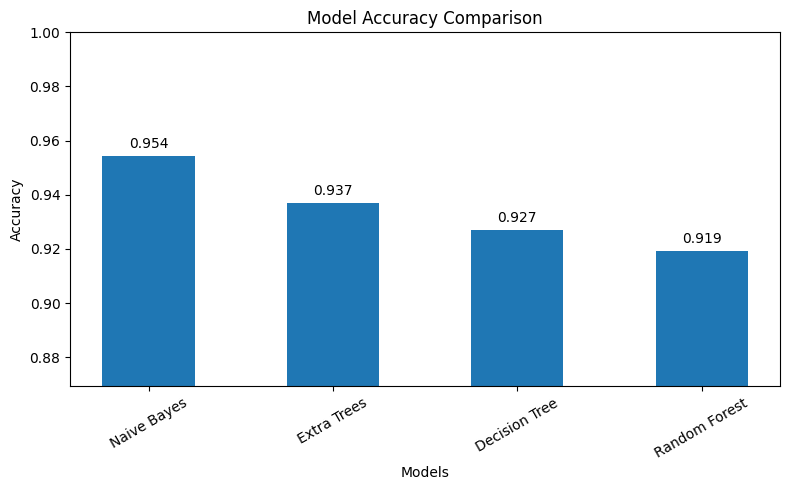

In [121]:
import matplotlib.pyplot as plt

sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

models = list(sorted_results.keys())
accuracies = list(sorted_results.values())

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.002,
        f"{yval:.3f}",
        ha='center',
        va='bottom'
    )

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(min(accuracies) - 0.05, 1.0)

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [122]:
import numpy as np

class EnsembleModel:
    def __init__(self, models, weights, voting='hard'):
        self.models = models
        self.weights = weights
        self.voting = voting

    def predict(self, X):
        if self.voting == 'soft':
            return self._soft_voting(X)
        else:
            return self._hard_voting(X)

    def _hard_voting(self, X):
        model_preds = {
            name: model.predict(X)
            for name, model in self.models.items()
        }

        final_preds = []

        for i in range(len(X)):
            votes = {}

            for name, preds in model_preds.items():
                pred = preds[i]
                weight = self.weights.get(name, 1)

                votes[pred] = votes.get(pred, 0) + weight

            final_pred = max(votes, key=votes.get)
            final_preds.append(final_pred)

        return np.array(final_preds)

    def _soft_voting(self, X):
        total_weight = sum(self.weights.values())
        weighted_probs = None

        for name, model in self.models.items():
            if not hasattr(model, "predict_proba"):
                raise ValueError(f"{name} does not support predict_proba")

            probs = model.predict_proba(X)
            weight = self.weights.get(name, 1)

            if weighted_probs is None:
                weighted_probs = weight * probs
            else:
                weighted_probs += weight * probs

        weighted_probs /= total_weight

        return np.argmax(weighted_probs, axis=1)

In [123]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Random Forest": rf_model,
    "Extra Trees": et_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model
}

weights = {
    "Random Forest": 1,
    "Extra Trees": 2,
    "Naive Bayes": 4,
    "Decision Tree": 1
}

In [124]:
ensemble_model = EnsembleModel(models, weights)

ensemble_preds = ensemble_model.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_preds))
print("Ensemble F1 Score:", f1_score(y_test, ensemble_preds, average='weighted'))

Ensemble Accuracy: 0.9489905232797693
Ensemble F1 Score: 0.9494709056368409


Now we will start testing the application, with a sample scenario, now will have user give some symptoms, the the model will try to make a prediction, if the model is not able to make a accurate prediction it will ask up on follow-up questions

In [ ]:
ATS5_DISEASES = [
    d for d, level in SELECTED_DISEASES.items() if level == 5
]

all_symptoms = X.columns.tolist()
symptom_index = {s: i for i, s in enumerate(all_symptoms)}

COMMON_MISTAKES = {
    "vomitting": "vomiting",
    "feaver": "fever"
}

CRITICAL_DISEASES = {
    "sepsis", "meningitis", "heart attack",
    "stroke", "cardiac arrest"
}

def normalize(symptoms):
    return [COMMON_MISTAKES.get(s, s) for s in symptoms]

def create_input(symptom_list):
    input_vector = [0] * len(all_symptoms)

    for s in symptom_list:
        s = s.lower().strip()
        if s in symptom_index:
            input_vector[symptom_index[s]] = 1

    return pd.DataFrame([input_vector], columns=all_symptoms)

# =========================
# ENSEMBLE
# =========================

def ensemble_predict_proba(input_df):
    probs = None
    total_weight = 9

    model_probs = [
        (rf_model.predict_proba(input_df), 1),
        (et_model.predict_proba(input_df), 2),
        (nb_model.predict_proba(input_df), 3),
        (dt_model.predict_proba(input_df), 1),
    ]

    for p, w in model_probs:
        if probs is None:
            probs = w * p
        else:
            probs += w * p

    probs /= total_weight
    return probs

# =========================
# PREDICTION
# =========================

def get_top_diseases(symptoms, top_n=3):
    input_df = create_input(symptoms)

    probs = ensemble_predict_proba(input_df)[0]
    classes = rf_model.classes_

    sorted_idx = np.argsort(probs)[::-1]
    results = [(classes[i], probs[i]) for i in sorted_idx]

    filtered = [
        (d, p) for d, p in results
        if not (d in CRITICAL_DISEASES and p < 0.3)
    ]

    if not filtered:
        filtered = results

    return sorted(filtered, key=lambda x: x[1], reverse=True)[:top_n]

def check_common_conditions(symptoms):
    input_df = create_input(symptoms)

    probs = ensemble_predict_proba(input_df)[0]
    classes = rf_model.classes_

    idx = np.argmax(probs)
    disease = classes[idx]
    confidence = probs[idx]

    if disease in ATS5_DISEASES and confidence > 0.3:
        return disease, confidence

    return None, None

def get_followup_questions(diseases, df, user_symptoms, top_n=5):
    disease_names = [d[0] for d in diseases]

    subset = df[df["diseases"].isin(disease_names)]

    symptom_cols = [
        col for col in df.columns
        if col not in ["diseases", "ats_level", "ats_label"]
    ]

    symptom_counts = subset[symptom_cols].sum().sort_values(ascending=False)

    user_symptoms = set(user_symptoms)

    filtered = [s for s in symptom_counts.index if s not in user_symptoms]

    return filtered[:top_n]

# =========================
# MAIN SYSTEM
# =========================

def symptom_checker():
    user_input = input("Enter your symptoms: ")
    user_symptoms = [s.strip().lower() for s in user_input.split(",") if s.strip()]
    user_symptoms = normalize(user_symptoms)

    disease, confidence = check_common_conditions(user_symptoms)

    if disease:
        print(f"\nLikely mild condition: {disease} ({confidence:.2f})")
        print("Advice: Self-care or visit GP if needed")
        return disease, confidence, user_symptoms

    print("\nSymptoms unclear. Let's refine further...")

    follow_up = get_followup_questions(
        get_top_diseases(user_symptoms),
        filtered_df,
        user_symptoms
    )

    print("Do you also have:")
    print(", ".join(follow_up))

    more = input("Additional symptoms: ")

    if more:
        user_symptoms.extend(
            normalize([s.strip().lower() for s in more.split(",")])
        )

    input_df = create_input(user_symptoms)

    probs = ensemble_predict_proba(input_df)[0]
    classes = rf_model.classes_

    idx = np.argmax(probs)
    final_pred = classes[idx]
    confidence = probs[idx]

    if confidence < 0.25:
        print("\nStill uncertain. Please consult a doctor.")
        return None, None, user_symptoms

    print(f"\nFinal Prediction: {final_pred} ({confidence:.2f})")

    return final_pred, confidence, user_symptoms

# =========================
# ATS OUTPUT
# =========================

def get_ats_output(disease, confidence):

    if confidence < 0.25:
        return "Unknown", "Low confidence. Please consult a GP."

    ats = SELECTED_DISEASES.get(disease, "Unknown")

    if ats == 1:
        advice = "Call emergency services immediately"
    elif ats == 2:
        advice = "Go to hospital immediately"
    elif ats == 3:
        advice = "Seek urgent medical care"
    elif ats == 4:
        advice = "Visit a GP"
    elif ats == 5:
        advice = "Self-care or routine check"
    else:
        advice = "Consult a healthcare provider"

    return ats, advice

# =========================
# RUN
# =========================

disease, confidence, symptoms = symptom_checker()

if disease:
    ats, advice = get_ats_output(disease, confidence)

    print("\nATS Level:", ats)
    print("Advice:", advice)